# 11. Trayectoria acumulada

Este notebook resume la trayectoria acumulada a lo largo de la secuencia y compara distintas estrategias de registro aplicadas sobre la pseudo-LiDAR frontal.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

BASE_DIR = Path('/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061')
trajectory_path = BASE_DIR / 'accumulated_trajectory_comparison.json'
trajectory_data = json.loads(trajectory_path.read_text())

agg_df = pd.DataFrame({
    name: info['aggregate']
    for name, info in trajectory_data['trajectories'].items()
}).T.sort_values('final_translation_error_m')
agg_df


,mean_translation_error_m,mean_rotation_error_deg,final_translation_error_m,final_rotation_error_deg,num_frames
front_baseline_cfg05,2.060046,2.855967,3.913382,3.709429,5.0
front_narrow_cfg05,1.682868,3.272136,4.288731,5.071131,5.0
front_icp_only,4.716126,5.205820,6.583026,5.526156,5.0


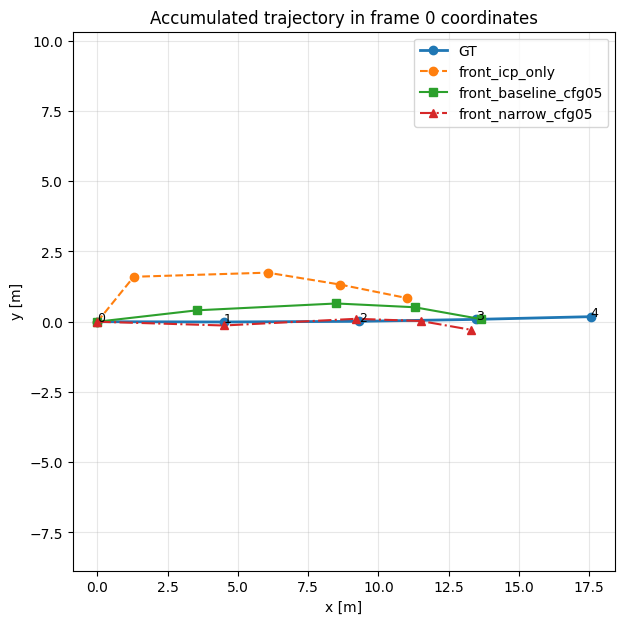

In [2]:
gt_xy = trajectory_data['gt_trajectory_xy']
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot([p[0] for p in gt_xy], [p[1] for p in gt_xy], '-o', label='GT', linewidth=2)

styles = {
    'front_icp_only': ('--o', 'front_icp_only'),
    'front_baseline_cfg05': ('-s', 'front_baseline_cfg05'),
    'front_narrow_cfg05': ('-.^', 'front_narrow_cfg05'),
}

for name, (style, label) in styles.items():
    xy = trajectory_data['trajectories'][name]['trajectory_xy']
    ax.plot([p[0] for p in xy], [p[1] for p in xy], style, label=label)

for idx, p in enumerate(gt_xy):
    ax.text(p[0], p[1], str(idx), fontsize=9)

ax.set_title('Accumulated trajectory in frame 0 coordinates')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


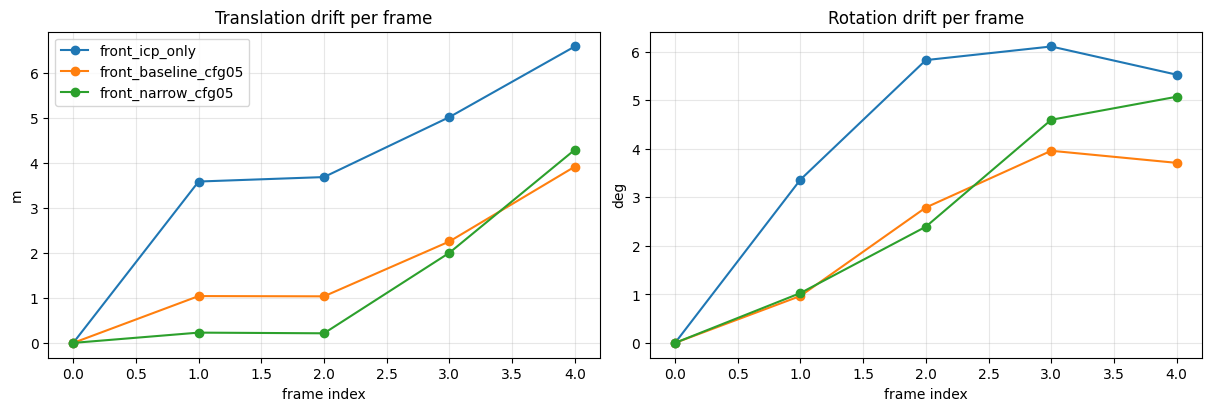

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
frame_ids = list(range(len(gt_xy)))

for name in styles:
    errs = trajectory_data['trajectories'][name]['frame_errors']
    axes[0].plot(frame_ids, [e['translation_error_m'] for e in errs], marker='o', label=name)
    axes[1].plot(frame_ids, [e['rotation_error_deg'] for e in errs], marker='o', label=name)

axes[0].set_title('Translation drift per frame')
axes[0].set_xlabel('frame index')
axes[0].set_ylabel('m')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Rotation drift per frame')
axes[1].set_xlabel('frame index')
axes[1].set_ylabel('deg')
axes[1].grid(True, alpha=0.3)

axes[0].legend()
plt.show()


In [4]:
pair_rows = []
for name, pairs in trajectory_data['pairwise_results'].items():
    for pair in pairs:
        if pair['metrics'] is None:
            continue
        pair_rows.append({
            'strategy': name,
            'pair_index': pair['pair_index'],
            **pair['metrics'],
        })
pair_df = pd.DataFrame(pair_rows)
pair_df


,strategy,pair_index,fitness,rmse,translation_error_m,rotation_error_deg
0,front_icp_only,0,0.800401,0.683366,3.690438,3.364125
1,front_icp_only,1,0.651527,0.616864,0.614648,2.854458
2,front_icp_only,2,0.697279,0.621831,1.615969,1.923987
3,front_icp_only,3,0.858325,0.661927,1.702555,1.179025
4,front_baseline_cfg05,0,0.779000,0.648207,1.062547,0.967031
5,front_baseline_cfg05,1,0.657501,0.606947,0.501333,2.242464
6,front_baseline_cfg05,2,0.697523,0.592791,1.411827,1.980360
7,front_baseline_cfg05,3,0.857689,0.628357,1.752093,1.247750
8,front_narrow_cfg05,0,0.754041,0.602138,0.294383,1.027496
9,front_narrow_cfg05,1,0.746106,0.589849,0.386038,2.012009


## Lectura rápida

- La tabla superior resume el error medio y el error final acumulado.
- La gráfica XY permite comprobar si la trayectoria estimada sigue la forma general de la trayectoria GT.
- Las curvas por frame permiten observar si la deriva crece de forma progresiva o si aparecen saltos puntuales.
